# Eksperimen Q-Learning Scenario B

State: `(current_node, progress_bin)` — agen mengetahui node dan kategori progres jarak.

Notebook ini tidak menduplikasi implementasi. Semua konfigurasi, download/load OSM, environment, reward, Q-Learning, metrik, grafik, dan peta berasal dari `rute_lari_core.py`.

In [10]:
%pip install -q "osmnx>=2.0" networkx numpy pandas geopandas shapely folium matplotlib pyproj

Note: you may need to restart the kernel to use updated packages.


## 1. Muat graf dengan core bersama

Jika GraphML belum ada, fungsi berikut mengunduh data OSM dengan konfigurasi yang sama seperti notebook analisis. Jika sudah ada, GraphML dimuat tanpa mengunduh ulang.

In [13]:
import importlib
import rute_lari_core

# Memuat ulang core agar perubahan grafik terbaru terbaca tanpa restart kernel.
importlib.reload(rute_lari_core)

from rute_lari_core import (
    load_or_download_graph,
    run_scenario_experiment,
    EPISODES,
    SEEDS,
)

G, START_NODE, GRAPH_PATH, downloaded_now = load_or_download_graph()

print(f'Graf: {G.number_of_nodes():,} node, {G.number_of_edges():,} edge')
print(f'Node start: {START_NODE}')
print(f'GraphML: {GRAPH_PATH}')
print('Sumber graf:', 'download baru' if downloaded_now else 'GraphML yang sudah ada')
print(f'Training: {len(SEEDS)} seed × {EPISODES:,} episode')

Graf: 8,027 node, 21,374 edge
Node start: 1720975931
GraphML: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/data_osm_5km/graf_jalan_kaki_5km.graphml
Sumber graf: GraphML yang sudah ada
Training: 5 seed × 2,500 episode


## 2. Eksperimen sensitivitas jumlah episode

Eksperimen ini menguji dampak jumlah episode training pada Scenario B. Setiap cell melatih ulang lima seed dari awal; hasil pada satu jumlah episode bukan kelanjutan hasil jumlah episode lain. Graf, reward, action mask, state, seed, dan evaluasi greedy tetap sama. Hanya jumlah episode yang berubah.

Jalankan cell secara berurutan. Eksperimen lengkap mencakup 5 seed × (10.000 + 20.000 + 30.000 + 40.000 + 50.000) = 750.000 episode untuk scenario ini. Artefak setiap percobaan disimpan pada folder terpisah agar tidak saling menimpa.


### 2.1 Training 10.000 episode


Menjalankan Scenario B: 5 seed x 10,000 episode
seed=0: over_distance, 5.53 km, is_loop=False
seed=1: over_distance, 5.52 km, is_loop=False
seed=2: no_available_action, 5.49 km, is_loop=False
seed=3: no_available_action, 5.16 km, is_loop=False
seed=4: no_available_action, 4.00 km, is_loop=False
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,False,False,False,False,False
total_distance_m,5530.021427,5524.322755,5487.085777,5155.822305,4001.336421
absolute_distance_error_m,530.021427,524.322755,487.085777,155.822305,998.663579
total_reward,-58.915154,-50.146672,-169.115948,-48.815942,-100.676919
mean_comfort,0.780263,0.789976,0.735597,0.735719,0.727892
return_progress_ratio,0.642857,0.612903,0.448276,0.6,0.473684
distance_to_start_at_end_m,739.762134,636.234086,1466.180869,445.030741,456.967075
closing_action_available,False,False,False,False,False
termination_reason,over_distance,over_distance,no_available_action,no_available_action,no_available_action


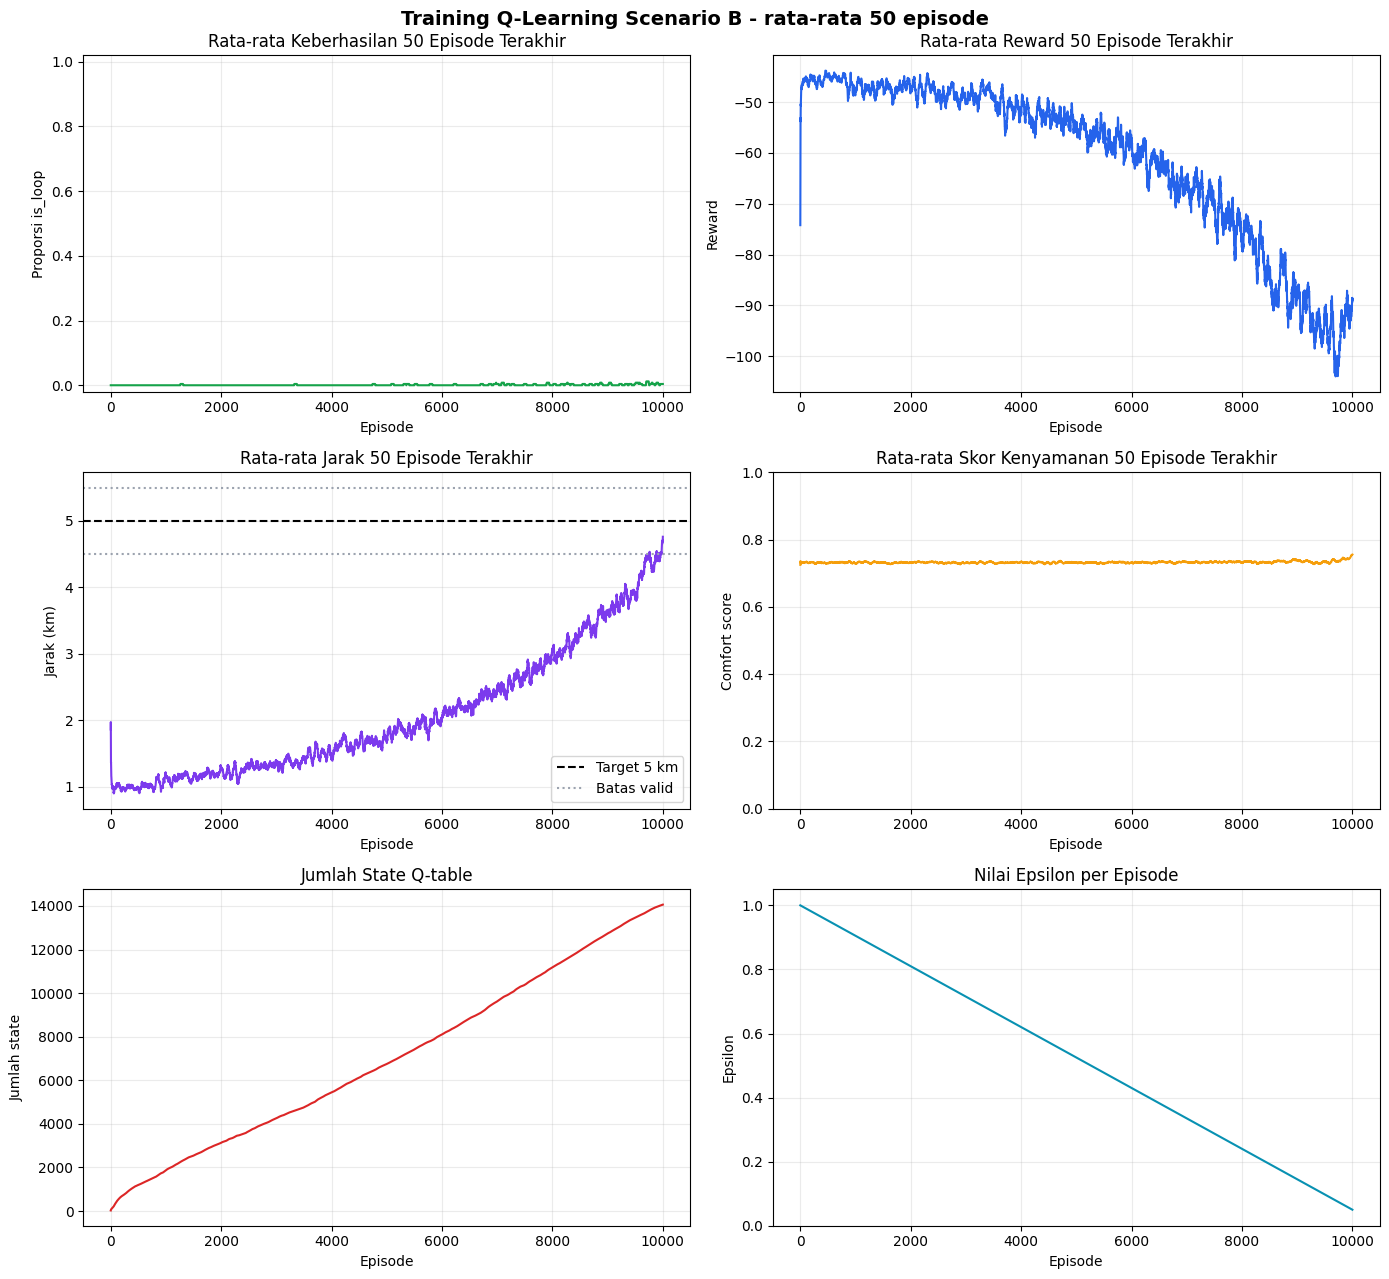

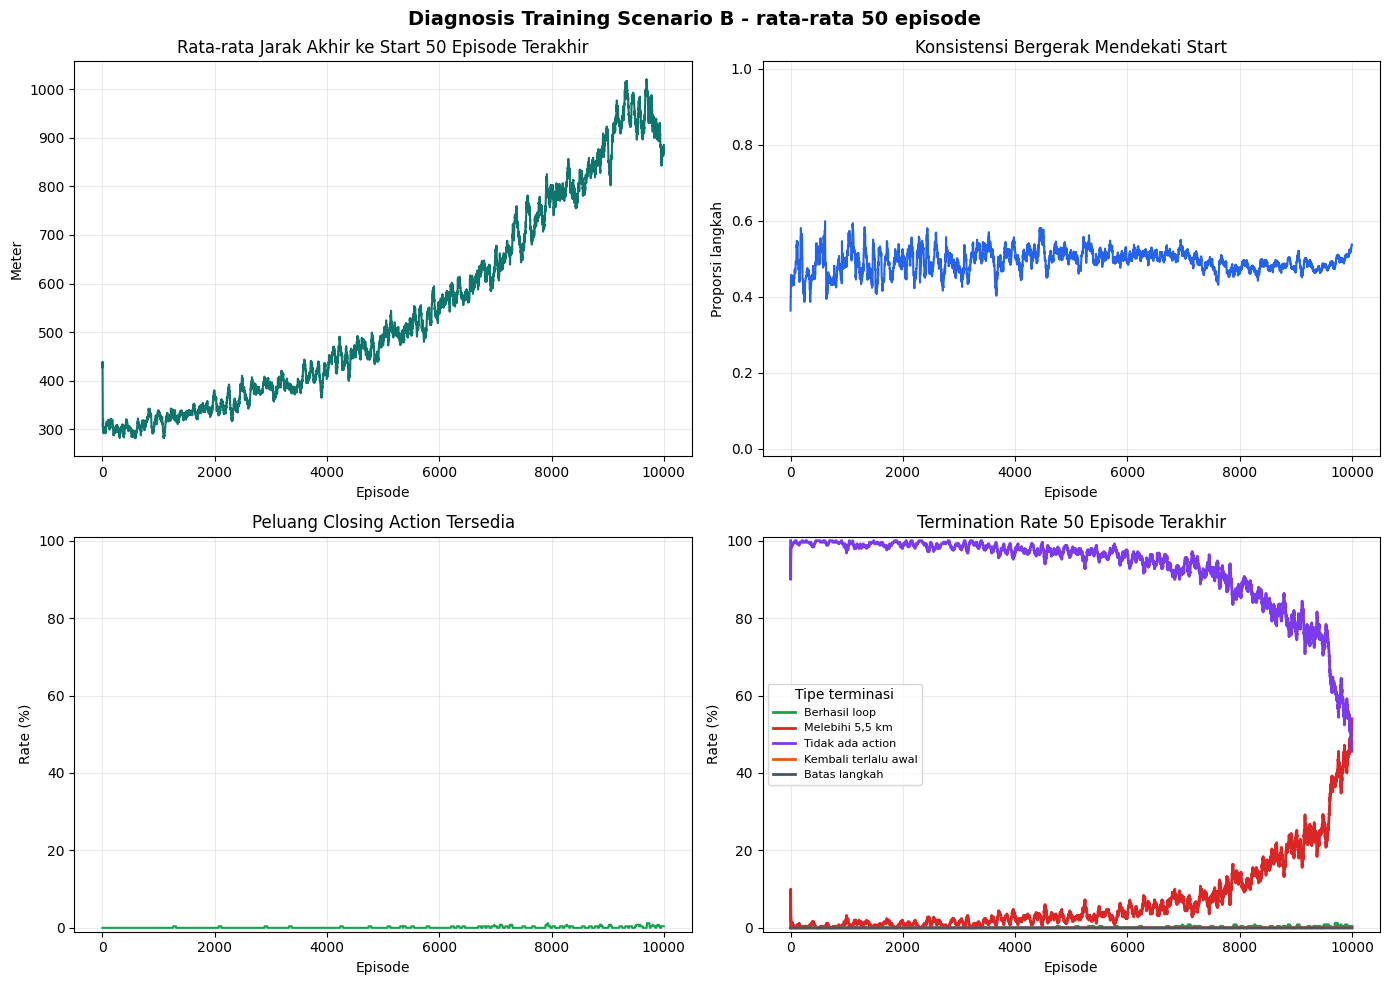

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: B; seed: 3
Metrik: is_loop=False, jarak=5155.82 m, galat=155.82 m, comfort=0.736, return_progress=0.600, jarak akhir ke start=445.03 m, terminasi=no_available_action
Alasan: Tidak ada loop valid, sehingga dipilih rute dengan galat jarak paling kecil; jika setara, jarak akhir ke start paling kecil, comfort tertinggi, lalu return progress tertinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_10000_B/training_history_B.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_10000_B/evaluation_metrics_B.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_10000_B/diagnosis_metrics_B.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_10000_B/termination_rates_training_B.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_10000_B/termination_rates_evaluation_B.csv
Grafik training utama: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/t

In [29]:
import importlib
# Memastikan kernel memakai versi core terbaru yang mendukung parameter episodes.
importlib.reload(rute_lari_core)

result_b_10000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'B', episodes=10_000,
    result_subdir='sensitivitas_episode_10000_B',
)


### 2.2 Training 20.000 episode


Menjalankan Scenario B: 5 seed x 20,000 episode
seed=0: no_available_action, 5.39 km, is_loop=False
seed=1: over_distance, 5.51 km, is_loop=False
seed=2: no_available_action, 5.49 km, is_loop=False
seed=3: over_distance, 5.74 km, is_loop=False
seed=4: over_distance, 5.60 km, is_loop=False
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,False,False,False,False,False
total_distance_m,5387.507171,5509.280536,5485.628338,5740.992554,5598.194727
absolute_distance_error_m,387.507171,509.280536,485.628338,740.992554,598.194727
total_reward,-51.300163,-58.57897,-76.811849,-66.318539,-66.916744
mean_comfort,0.773493,0.72657,0.776947,0.780393,0.783644
return_progress_ratio,0.647059,0.257143,0.541667,0.526316,0.470588
distance_to_start_at_end_m,343.148245,1572.561977,785.351978,757.297806,1206.953322
closing_action_available,False,False,False,False,False
termination_reason,no_available_action,over_distance,no_available_action,over_distance,over_distance


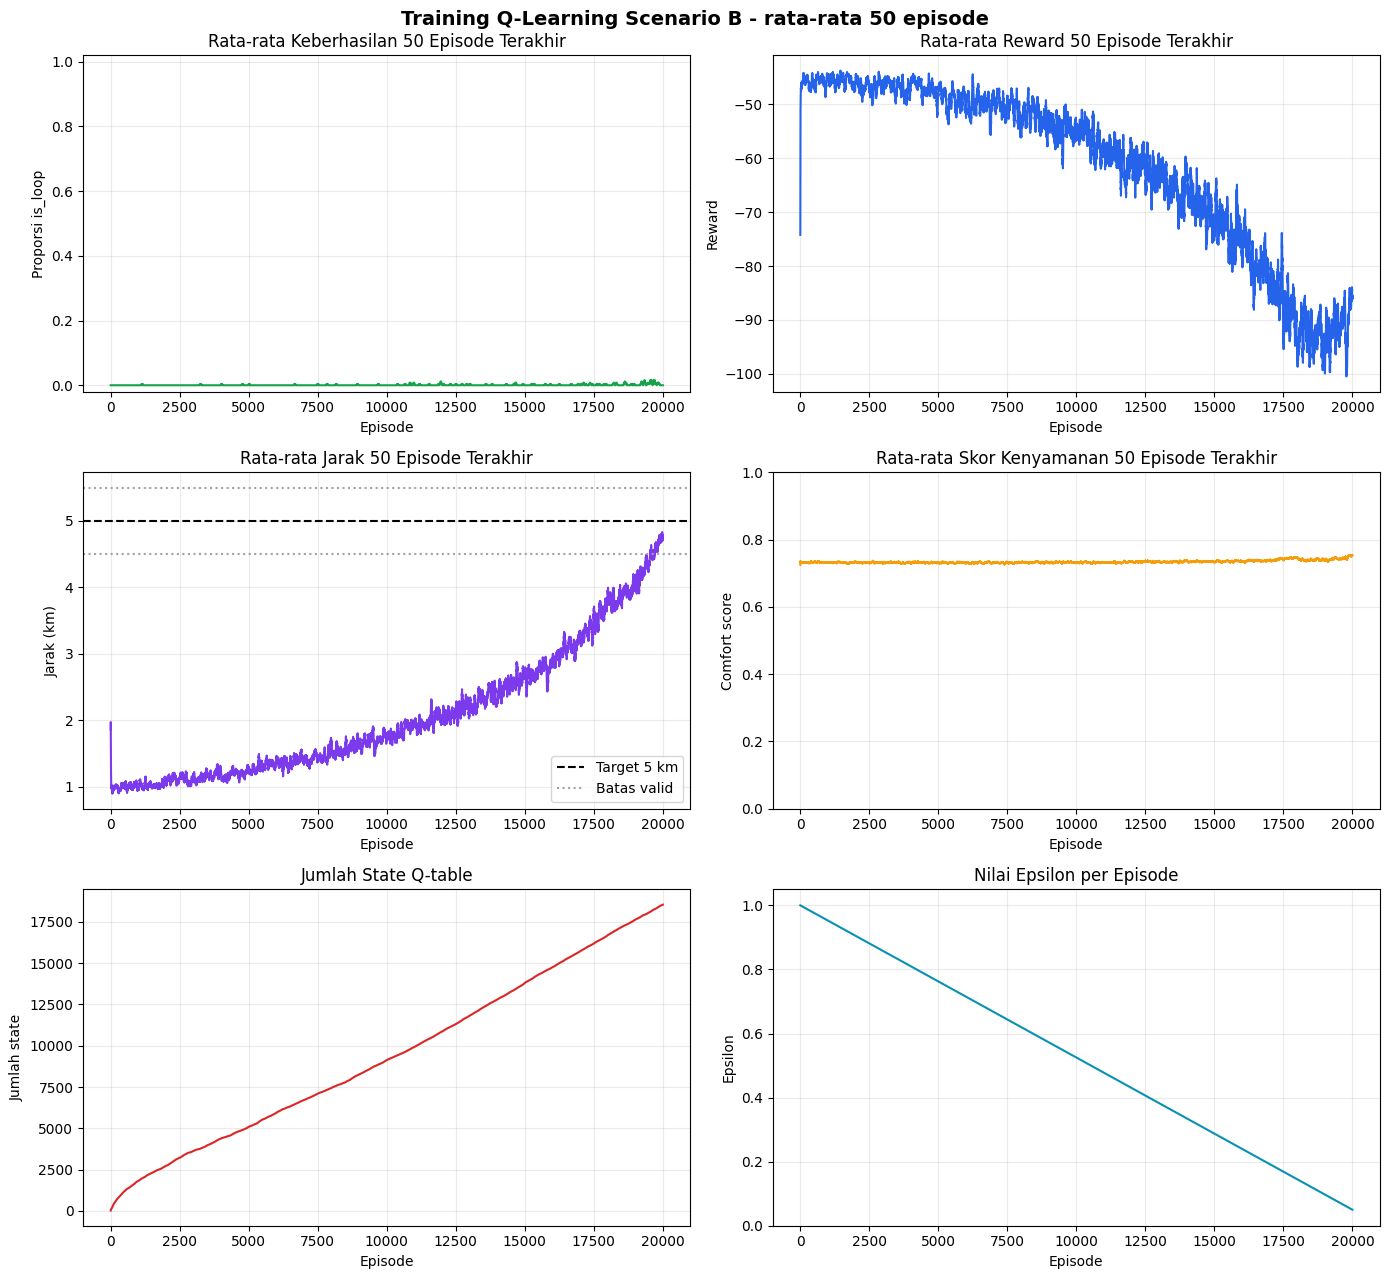

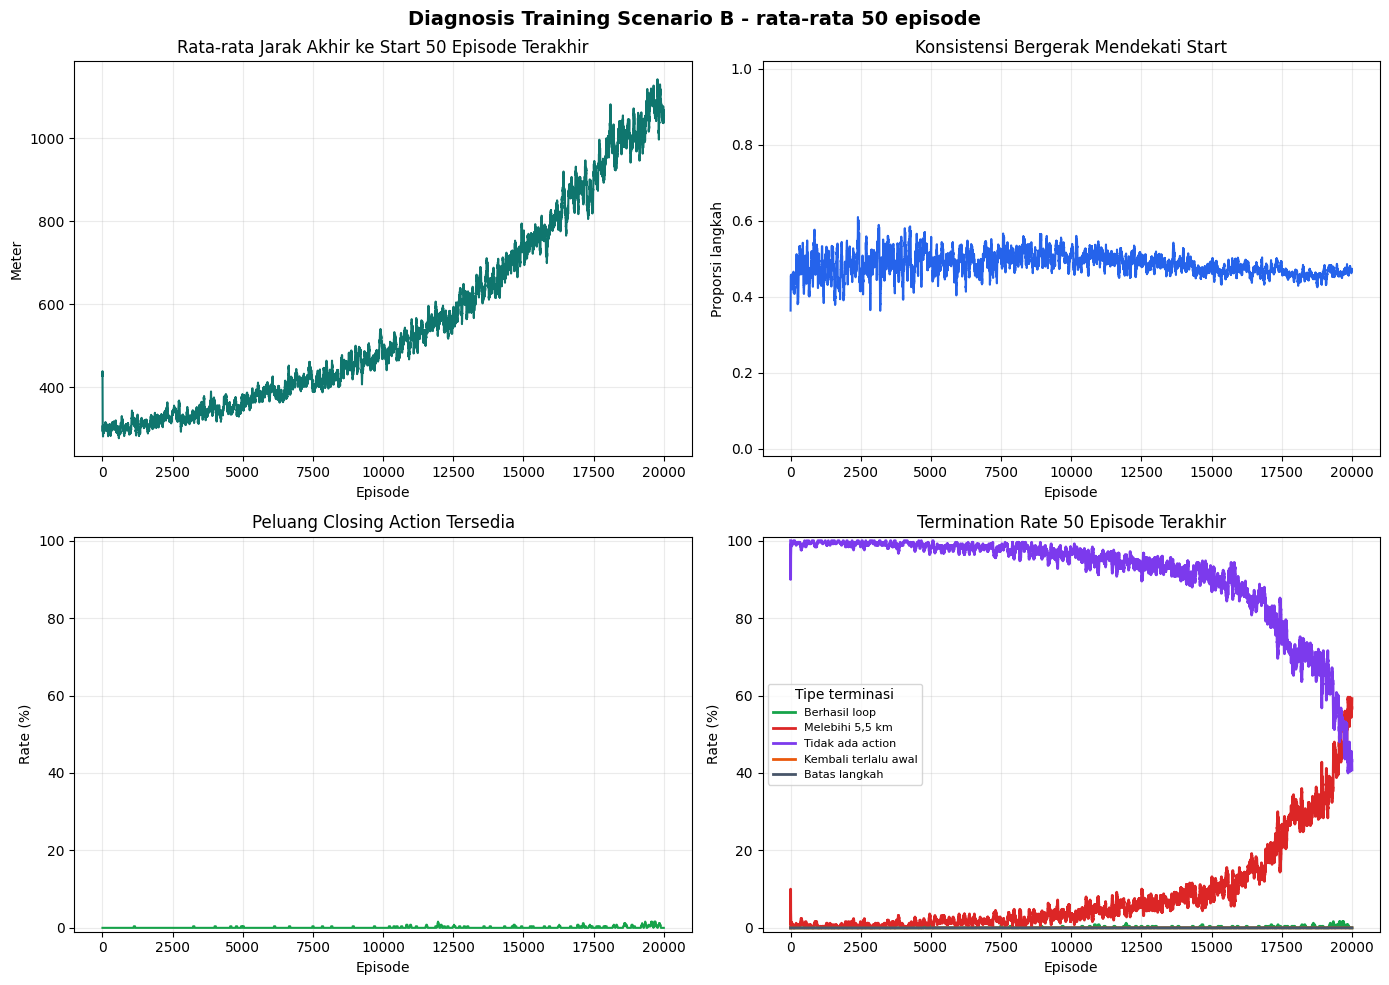

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: B; seed: 0
Metrik: is_loop=False, jarak=5387.51 m, galat=387.51 m, comfort=0.773, return_progress=0.647, jarak akhir ke start=343.15 m, terminasi=no_available_action
Alasan: Tidak ada loop valid, sehingga dipilih rute dengan galat jarak paling kecil; jika setara, jarak akhir ke start paling kecil, comfort tertinggi, lalu return progress tertinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_20000_B/training_history_B.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_20000_B/evaluation_metrics_B.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_20000_B/diagnosis_metrics_B.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_20000_B/termination_rates_training_B.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_20000_B/termination_rates_evaluation_B.csv
Grafik training utama: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/t

In [30]:
import importlib
# Memastikan kernel memakai versi core terbaru yang mendukung parameter episodes.
importlib.reload(rute_lari_core)

result_b_20000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'B', episodes=20_000,
    result_subdir='sensitivitas_episode_20000_B',
)


### 2.3 Training 30.000 episode


Menjalankan Scenario B: 5 seed x 30,000 episode
seed=0: over_distance, 5.54 km, is_loop=False
seed=1: no_available_action, 5.40 km, is_loop=False
seed=2: over_distance, 5.52 km, is_loop=False
seed=3: over_distance, 5.51 km, is_loop=False
seed=4: no_available_action, 5.12 km, is_loop=False
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,False,False,False,False,False
total_distance_m,5536.082425,5395.969116,5524.025253,5505.298283,5115.53977
absolute_distance_error_m,536.082425,395.969116,524.025253,505.298283,115.53977
total_reward,-73.885384,-146.384481,-96.012951,-85.799539,-105.477031
mean_comfort,0.779331,0.693597,0.776137,0.779508,0.777727
return_progress_ratio,0.486486,0.581818,0.55814,0.377358,0.47619
distance_to_start_at_end_m,712.382928,1158.43805,417.927701,1899.14039,1705.395653
closing_action_available,False,False,False,False,False
termination_reason,over_distance,no_available_action,over_distance,over_distance,no_available_action


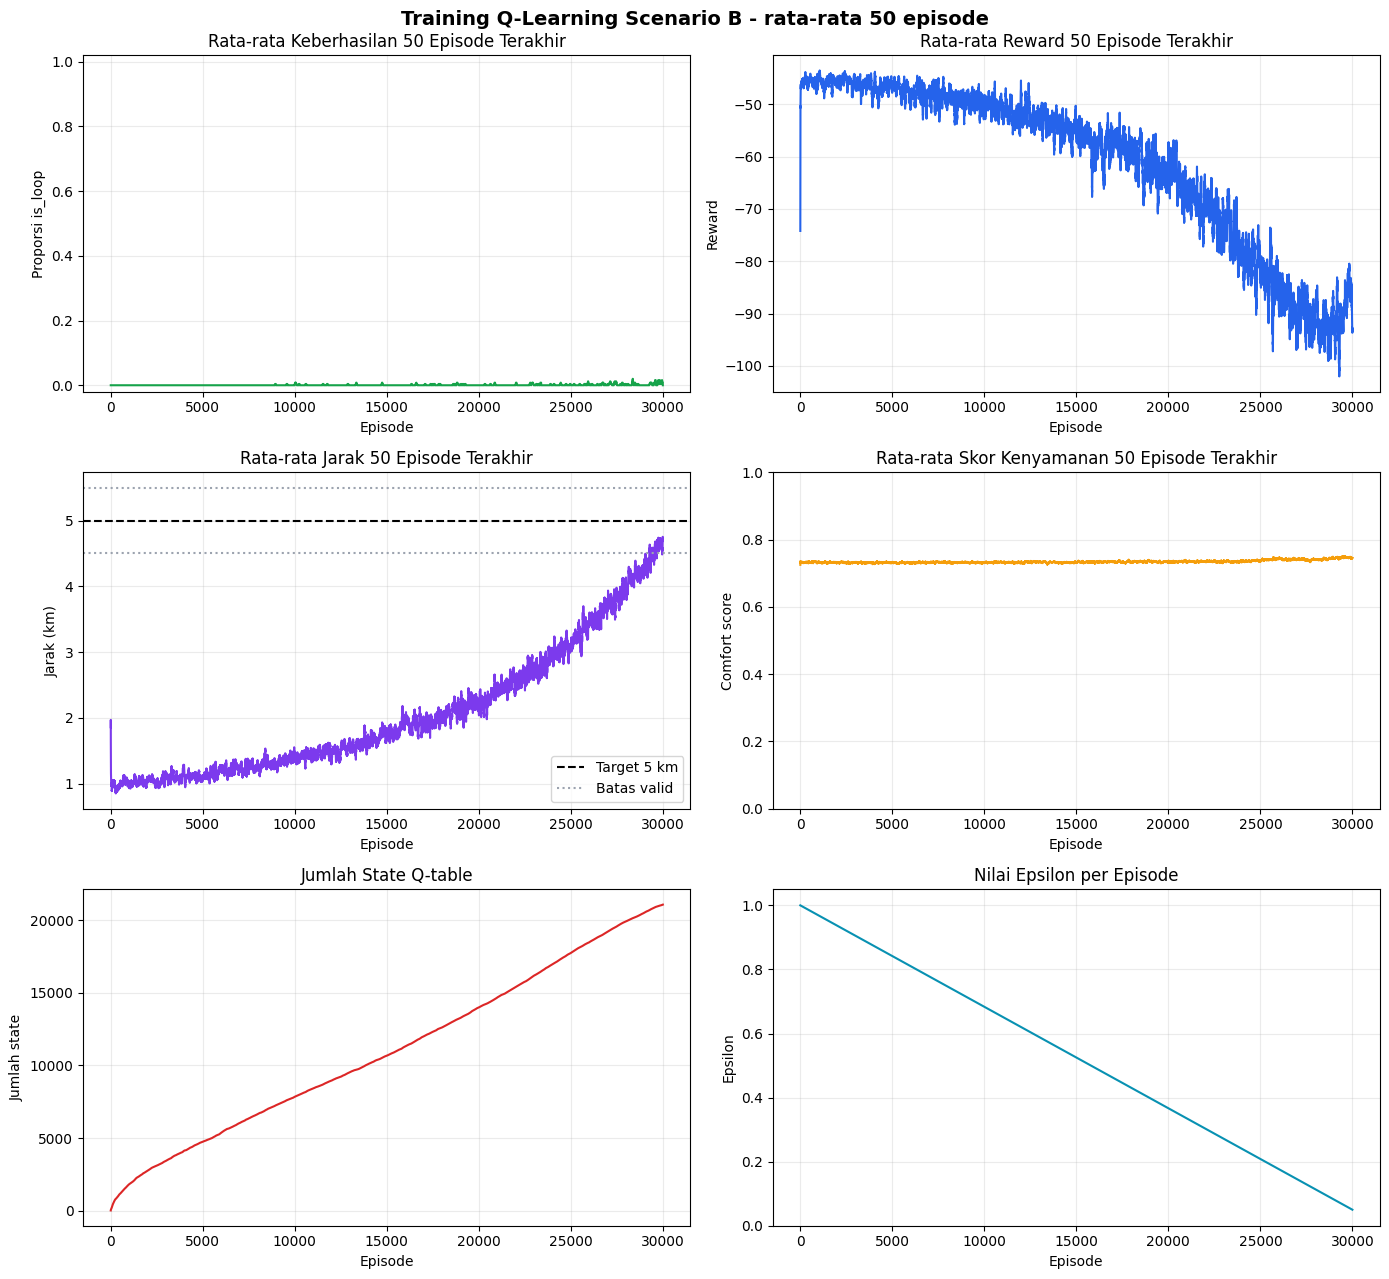

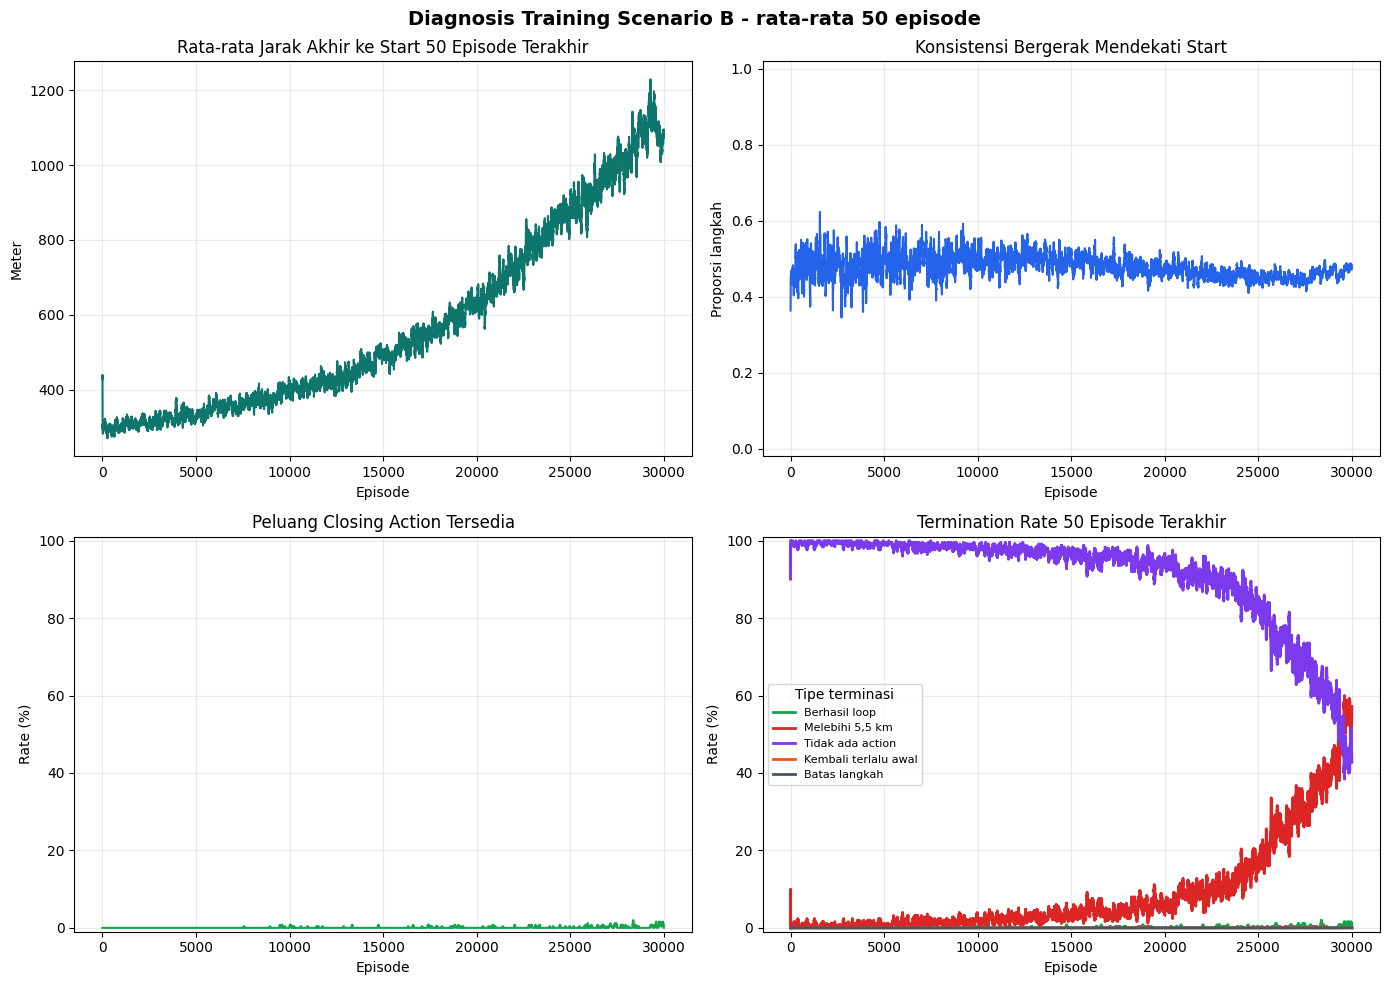

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: B; seed: 4
Metrik: is_loop=False, jarak=5115.54 m, galat=115.54 m, comfort=0.778, return_progress=0.476, jarak akhir ke start=1705.40 m, terminasi=no_available_action
Alasan: Tidak ada loop valid, sehingga dipilih rute dengan galat jarak paling kecil; jika setara, jarak akhir ke start paling kecil, comfort tertinggi, lalu return progress tertinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_30000_B/training_history_B.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_30000_B/evaluation_metrics_B.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_30000_B/diagnosis_metrics_B.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_30000_B/termination_rates_training_B.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_30000_B/termination_rates_evaluation_B.csv
Grafik training utama: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/t

In [31]:
import importlib
# Memastikan kernel memakai versi core terbaru yang mendukung parameter episodes.
importlib.reload(rute_lari_core)

result_b_30000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'B', episodes=30_000,
    result_subdir='sensitivitas_episode_30000_B',
)


### 2.4 Training 40.000 episode


Menjalankan Scenario B: 5 seed x 40,000 episode
seed=0: over_distance, 5.52 km, is_loop=False
seed=1: no_available_action, 5.23 km, is_loop=False
seed=2: over_distance, 5.52 km, is_loop=False
seed=3: success, 5.05 km, is_loop=True
seed=4: no_available_action, 5.18 km, is_loop=False
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,False,False,False,True,False
total_distance_m,5520.313227,5228.849443,5524.830308,5045.205771,5179.218443
absolute_distance_error_m,520.313227,228.849443,524.830308,45.205771,179.218443
total_reward,-123.736655,-96.85934,-65.351946,94.649677,-90.122481
mean_comfort,0.783027,0.775581,0.767419,0.707652,0.781167
return_progress_ratio,0.478261,0.478261,0.638889,0.828571,0.347826
distance_to_start_at_end_m,1408.232629,1601.583053,600.801826,0.0,1949.975153
closing_action_available,False,False,False,True,False
termination_reason,over_distance,no_available_action,over_distance,success,no_available_action


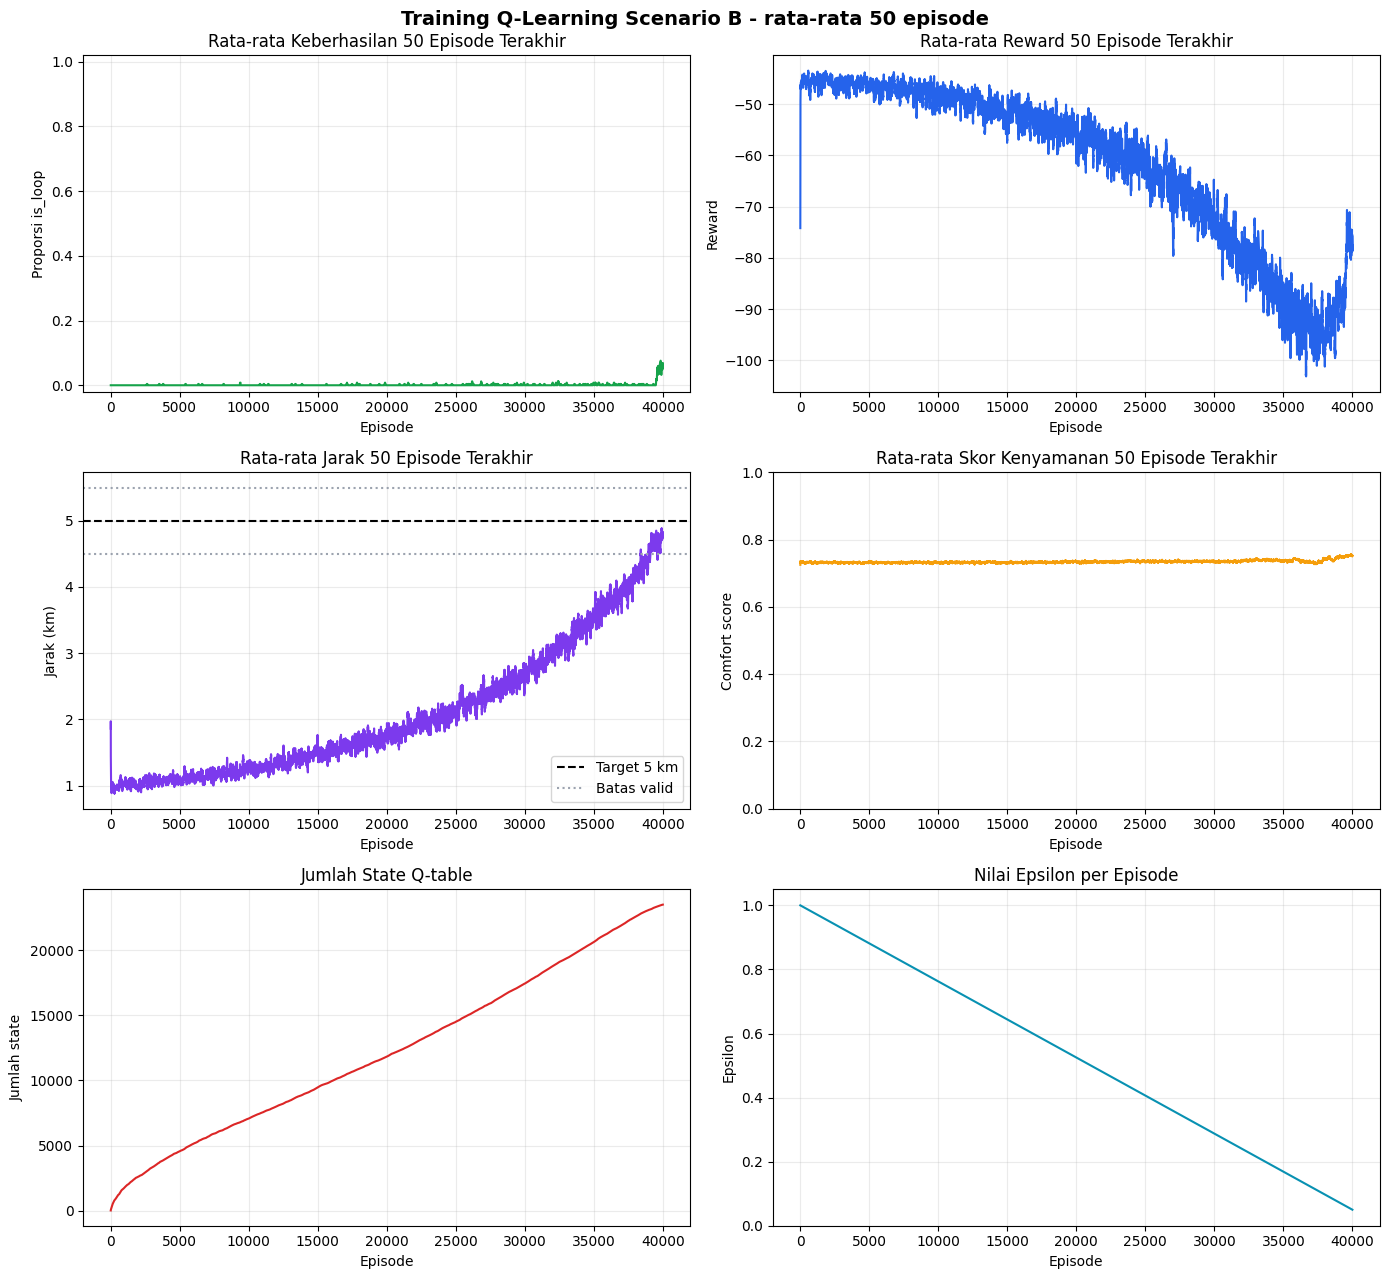

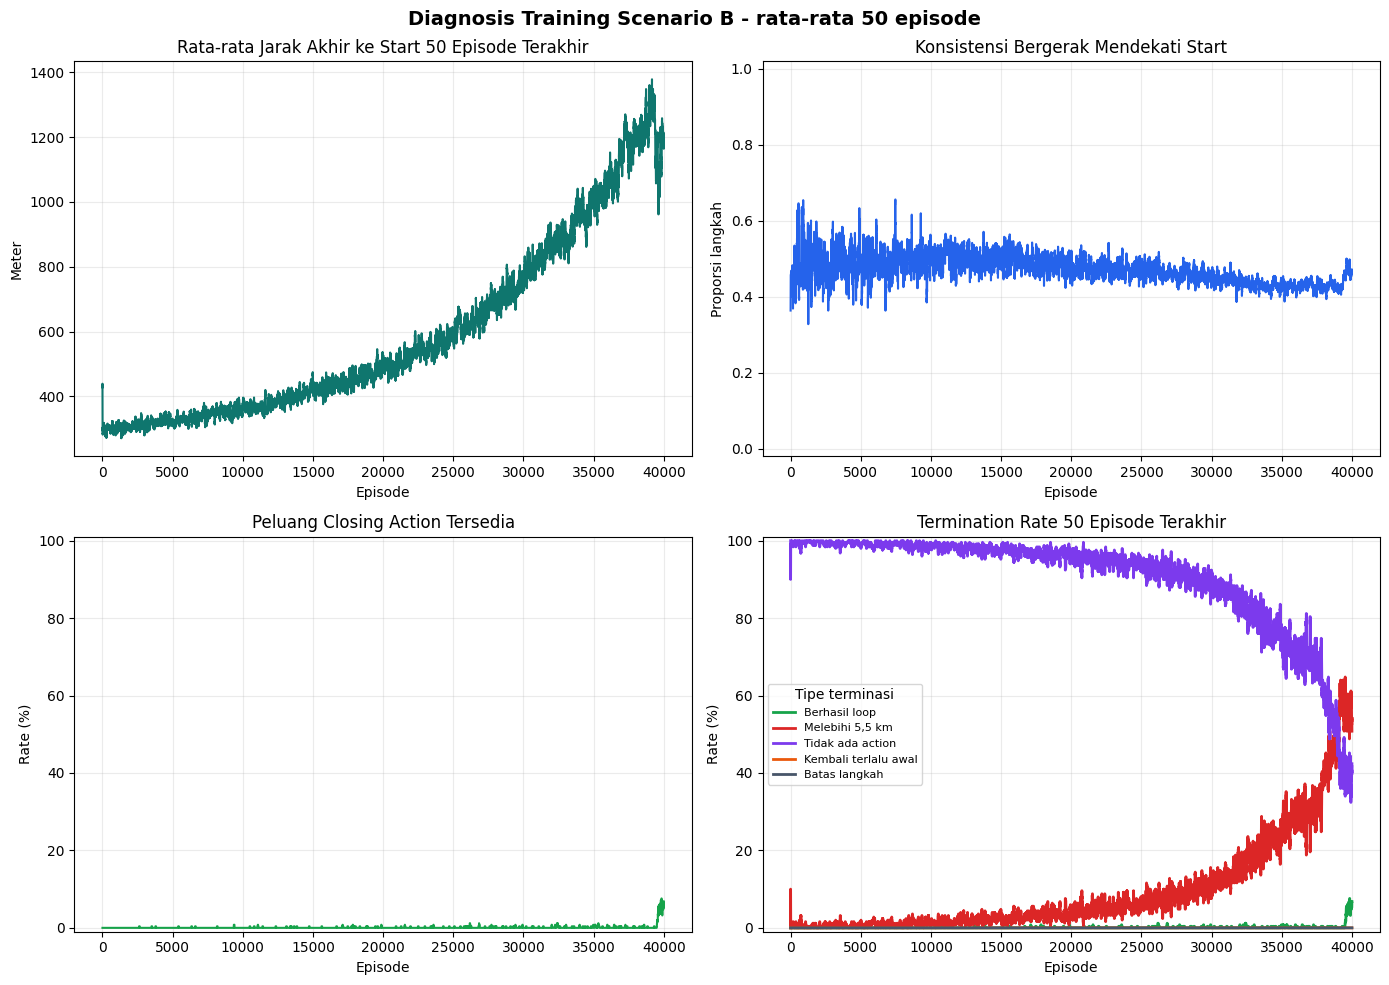

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: B; seed: 3
Metrik: is_loop=True, jarak=5045.21 m, galat=45.21 m, comfort=0.708, return_progress=0.829, jarak akhir ke start=0.00 m, terminasi=success
Alasan: Dipilih dari 1 loop valid: galat jarak paling kecil; jika setara, comfort lalu return progress lebih tinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_40000_B/training_history_B.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_40000_B/evaluation_metrics_B.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_40000_B/diagnosis_metrics_B.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_40000_B/termination_rates_training_B.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_40000_B/termination_rates_evaluation_B.csv
Grafik training utama: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/t

In [32]:
import importlib
# Memastikan kernel memakai versi core terbaru yang mendukung parameter episodes.
importlib.reload(rute_lari_core)

result_b_40000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'B', episodes=40_000,
    result_subdir='sensitivitas_episode_40000_B',
)


### 2.5 Training 50.000 episode


Menjalankan Scenario B: 5 seed x 100,000 episode
seed=0: over_distance, 5.51 km, is_loop=False
seed=1: over_distance, 5.55 km, is_loop=False
seed=2: over_distance, 5.52 km, is_loop=False
seed=3: over_distance, 5.53 km, is_loop=False
seed=4: no_available_action, 5.47 km, is_loop=False
Tampilan vertikal metrik evaluasi utama per seed


seed,0,1,2,3,4
is_loop,False,False,False,False,False
total_distance_m,5514.982978,5547.891701,5518.307031,5529.592425,5470.447776
absolute_distance_error_m,514.982978,547.891701,518.307031,529.592425,470.447776
total_reward,-56.284565,-72.76283,-67.476672,-145.83617,-61.927824
mean_comfort,0.751117,0.72851,0.732186,0.71968,0.753388
return_progress_ratio,0.384615,0.333333,0.25641,0.321429,0.25
distance_to_start_at_end_m,2144.686888,1793.38648,2791.323891,2062.643536,2803.520617
closing_action_available,False,False,False,False,False
termination_reason,over_distance,over_distance,over_distance,over_distance,no_available_action


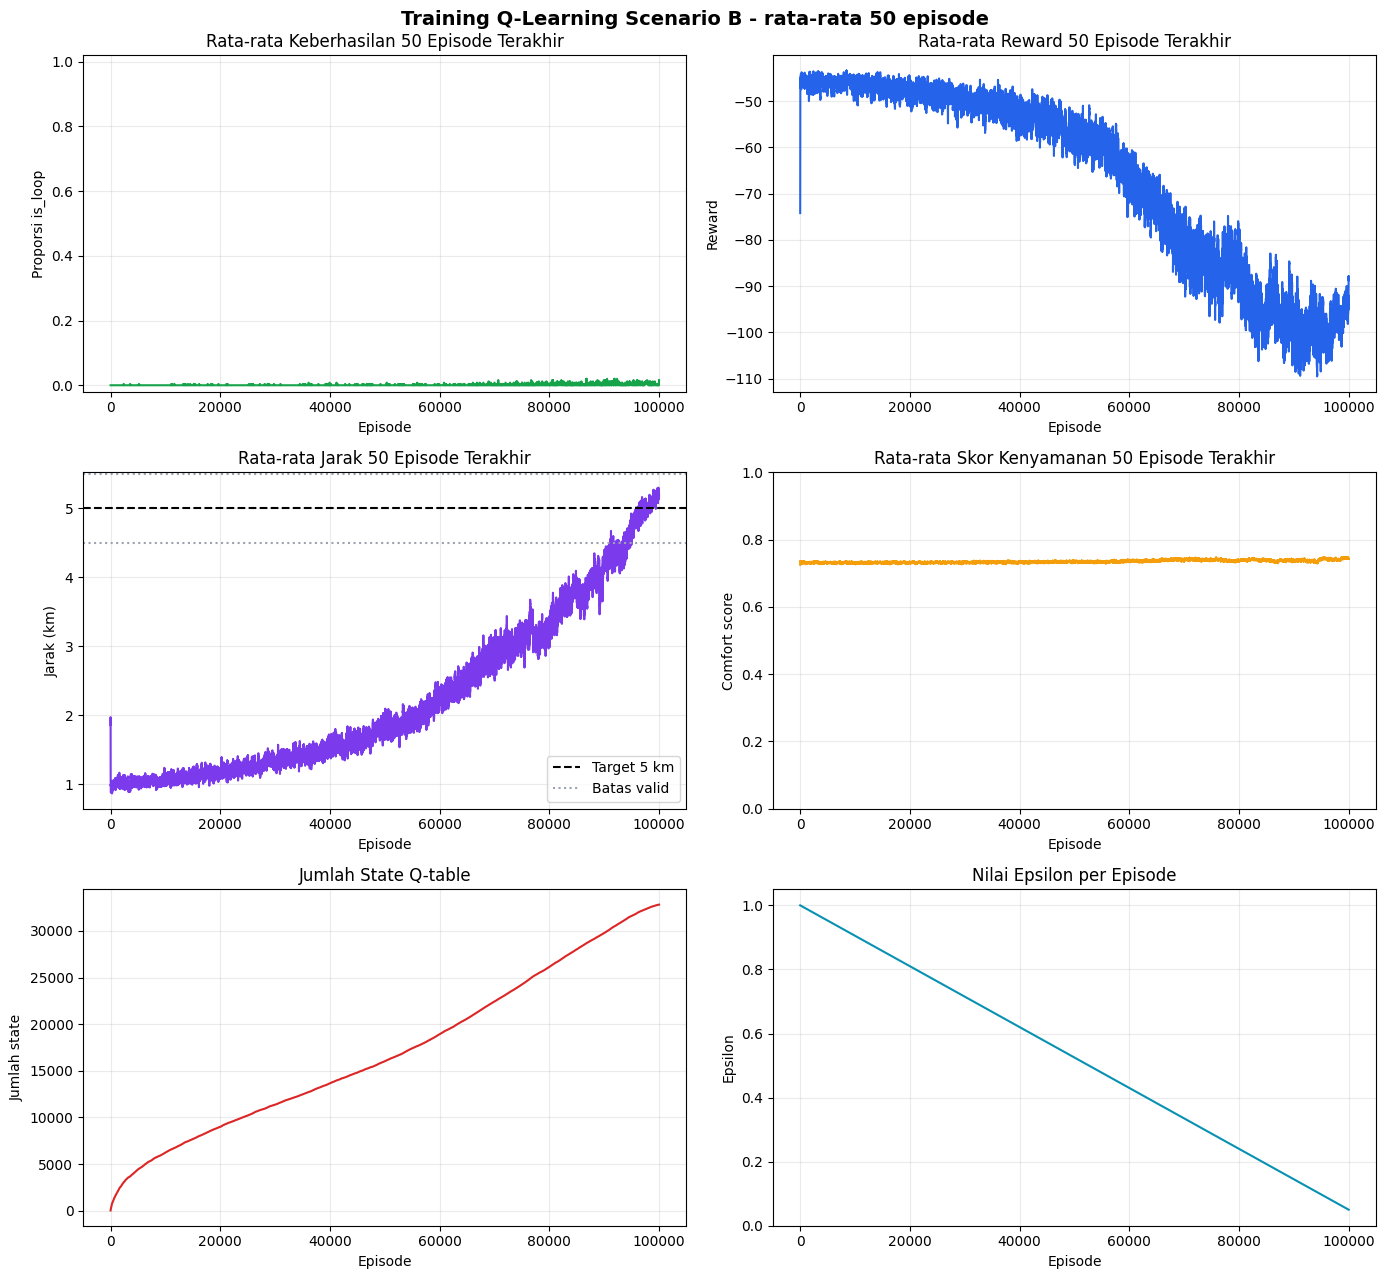

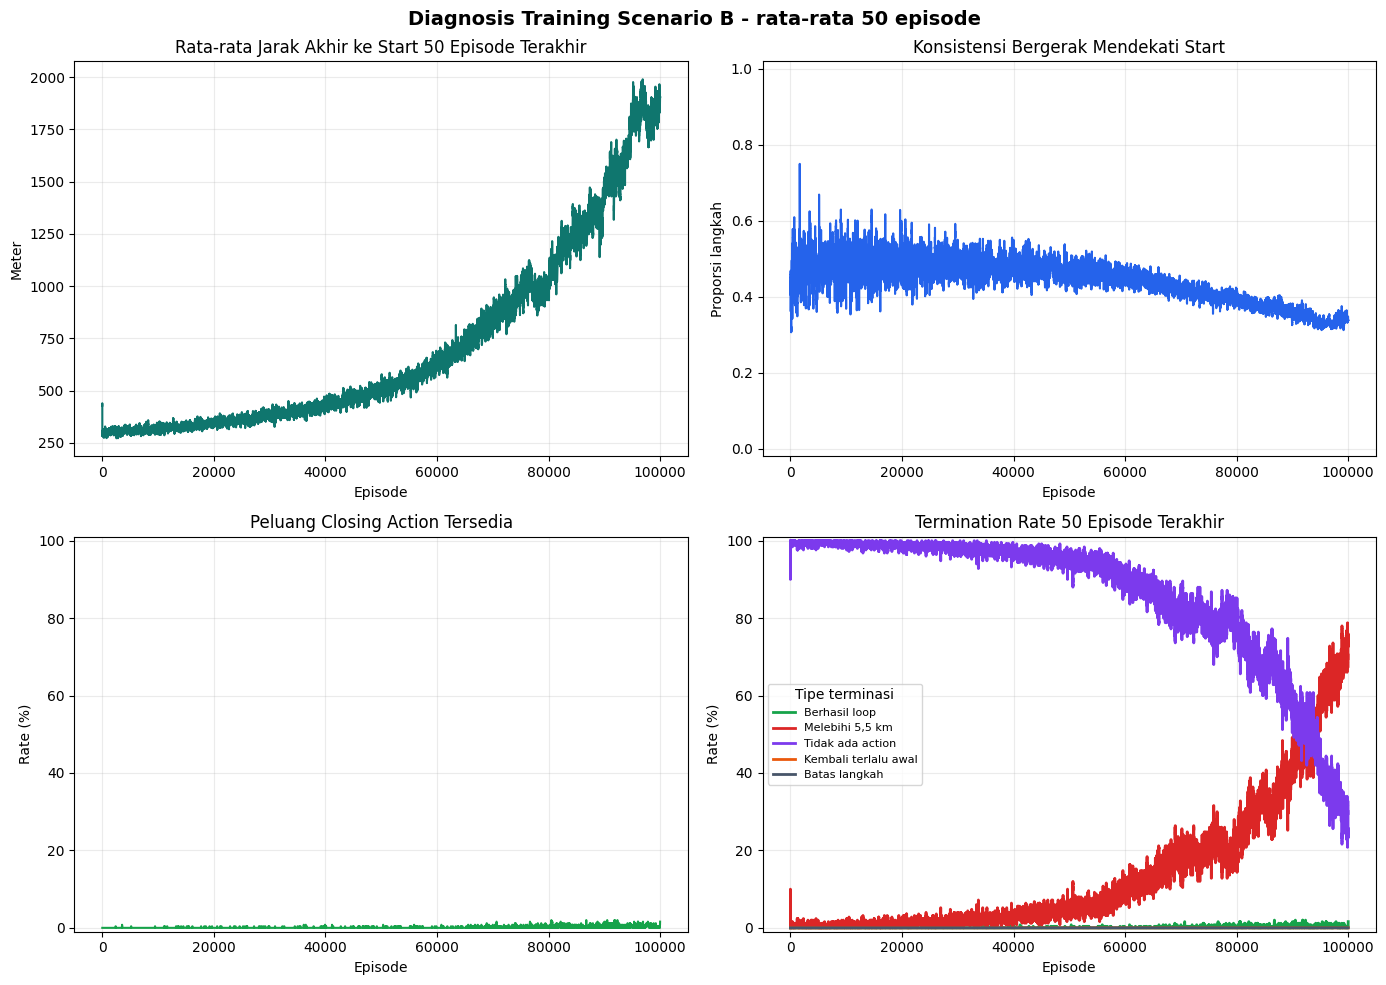

=== Q-TABLE / SEED YANG DIPILIH UNTUK PETA ===
Scenario: B; seed: 4
Metrik: is_loop=False, jarak=5470.45 m, galat=470.45 m, comfort=0.753, return_progress=0.250, jarak akhir ke start=2803.52 m, terminasi=no_available_action
Alasan: Tidak ada loop valid, sehingga dipilih rute dengan galat jarak paling kecil; jika setara, jarak akhir ke start paling kecil, comfort tertinggi, lalu return progress tertinggi.


History: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_50000_B/training_history_B.csv
Evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_50000_B/evaluation_metrics_B.csv
Diagnosis: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_50000_B/diagnosis_metrics_B.csv
Termination rate training: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_50000_B/termination_rates_training_B.csv
Termination rate evaluasi: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/training_qlearning_5km/sensitivitas_episode_50000_B/termination_rates_evaluation_B.csv
Grafik training utama: /Users/davidprastiyaimannuel/widya_kartika/david-31123022-tugas-akhir/hasil_bab_4/t

In [35]:
import importlib
# Memastikan kernel memakai versi core terbaru yang mendukung parameter episodes.
importlib.reload(rute_lari_core)

result_b_50000 = rute_lari_core.run_scenario_experiment(
    G, START_NODE, 'B', episodes=50_000,
    result_subdir='sensitivitas_episode_50000_B',
)


### 2.6 Ringkasan perbandingan

Tabel dan grafik berikut memakai evaluasi greedy lima seed dari setiap jumlah episode. `success_rate_greedy` adalah proporsi seed yang membentuk loop valid. Bandingkan terutama keberhasilan loop, galat jarak, return progress ratio, dan peluang closing action tersedia.


,episodes,success_rate_greedy,mean_distance_error_m,mean_total_reward,mean_comfort,mean_return_progress_ratio,closing_action_available_rate
0,10000,0.0,539.183168,-85.534127,0.753889,0.555544,0.0
1,20000,0.0,544.320665,-63.985253,0.768209,0.488554,0.0
2,30000,0.0,415.382969,-101.511877,0.761260,0.495999,0.0
3,40000,0.2,299.683438,-56.284149,0.762969,0.554362,0.2
4,50000,0.0,499.360851,-84.106444,0.760773,0.316191,0.0


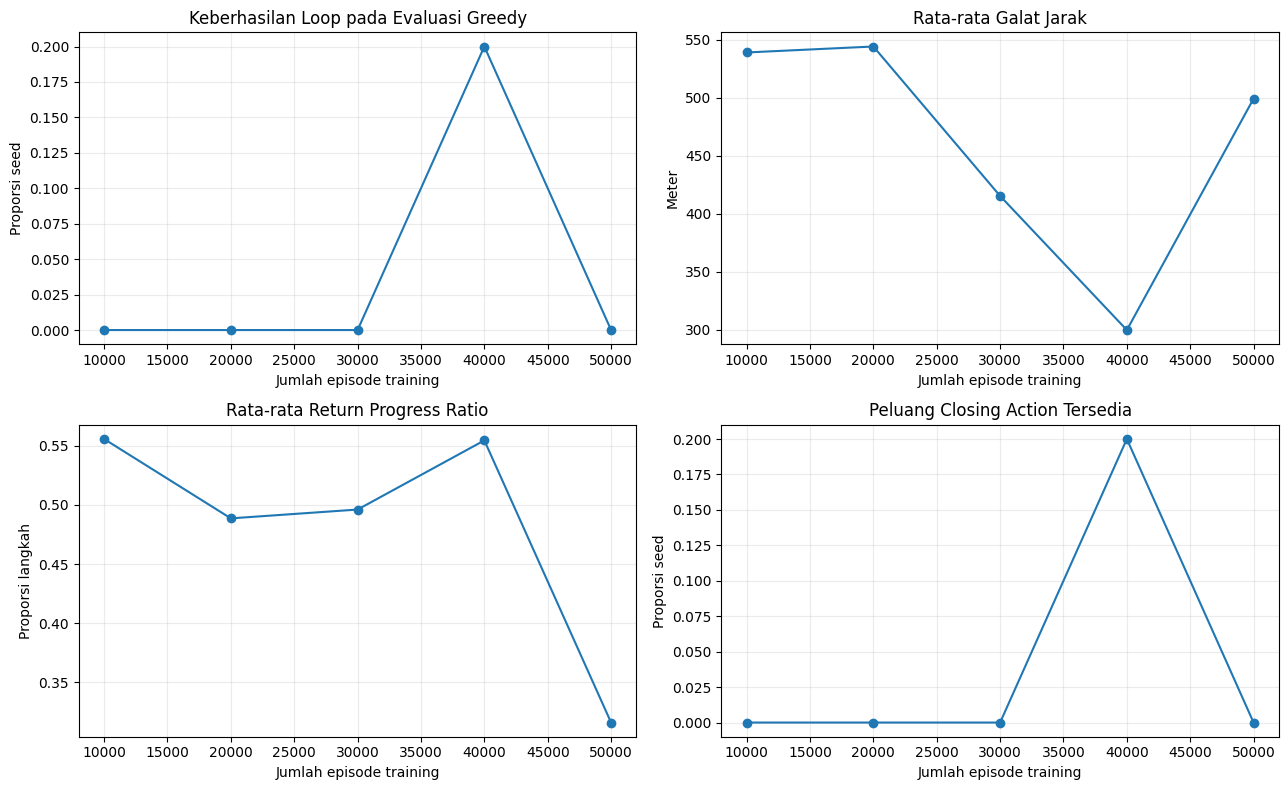

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

episode_results = {
    10_000: result_b_10000,
    20_000: result_b_20000,
    30_000: result_b_30000,
    40_000: result_b_40000,
    50_000: result_b_50000,
}

summary_rows = []
for episodes, result in episode_results.items():
    metrics = result['metrics']
    summary_rows.append({
        'episodes': episodes,
        'success_rate_greedy': metrics['is_loop'].mean(),
        'mean_distance_error_m': metrics['absolute_distance_error_m'].mean(),
        'mean_total_reward': metrics['total_reward'].mean(),
        'mean_comfort': metrics['mean_comfort'].mean(),
        'mean_return_progress_ratio': metrics['return_progress_ratio'].mean(),
        'closing_action_available_rate': metrics['closing_action_available'].mean(),
    })

episode_sensitivity_df = pd.DataFrame(summary_rows).sort_values('episodes')
display(episode_sensitivity_df)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plots = [
    ('success_rate_greedy', 'Keberhasilan Loop pada Evaluasi Greedy', 'Proporsi seed'),
    ('mean_distance_error_m', 'Rata-rata Galat Jarak', 'Meter'),
    ('mean_return_progress_ratio', 'Rata-rata Return Progress Ratio', 'Proporsi langkah'),
    ('closing_action_available_rate', 'Peluang Closing Action Tersedia', 'Proporsi seed'),
]
for axis, (column, title, ylabel) in zip(axes.flat, plots):
    axis.plot(episode_sensitivity_df['episodes'], episode_sensitivity_df[column], marker='o')
    axis.set(title=title, xlabel='Jumlah episode training', ylabel=ylabel)
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 3. Cara membaca hasil evaluasi

Tabel evaluasi utama memuat `is_loop`, `total_distance_m`, `absolute_distance_error_m`, `total_reward`, `mean_comfort`, `return_progress_ratio`, `distance_to_start_at_end_m`, `closing_action_available`, dan `termination_reason`.

Grafik diagnosis tetap membantu menjelaskan proses training, khususnya termination rate dan ketersediaan closing action.

Baca detail seluruh implementasi di `IMPLEMENTASI.md`.